In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['NUMEXPR_NUM_THREADS'] = '2'
os.environ['VECLIB_MAXIMUM_THREADS'] = '2'

print("? Thread limits set to 2 in this notebook")

? Thread limits set to 2 in this notebook


In [1]:
# ==================== CELL 1: GAT Setup, training, and attack utilities ====================
import os
import random
import ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------- Load dataset ----------
CSV_PATH = "all_circuits_features.csv"   # your CSV file
df = pd.read_csv(CSV_PATH)

print("\nDataset head:")
print(df.head())

# ---------- Label encode gate_type ----------
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# ---------- Feature columns ----------
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

df = df.dropna(subset=feature_columns).reset_index(drop=True)
df[feature_columns] = df[feature_columns].astype(float)

# ---------- Standardize ----------
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# ---------- Build nodes & edges ----------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

print(f"\nExtracted {len(edges)} edges (approximate fan-in construction).")
if len(edges) == 0:
    raise ValueError("No edges found! Check fan_in/fan_out in CSV.")

src_nodes, dst_nodes = zip(*edges)
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# ---------- DGL graph ----------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)

graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# ---------- Train-test split ----------
num_nodes = graph.num_nodes()
indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# ---------- Define GAT ----------
class GAT(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_heads=4, attn_drop=0.2):
        super(GAT, self).__init__()
        self.gat1 = dglnn.GATConv(in_feats, hidden_feats, num_heads=num_heads, feat_drop=0.0, attn_drop=attn_drop, activation=nn.ELU())
        self.gat2 = dglnn.GATConv(hidden_feats * num_heads, out_feats, num_heads=1, feat_drop=0.0, attn_drop=attn_drop, activation=None)

    def forward(self, g, inputs):
        h = self.gat1(g, inputs)
        h = h.flatten(1)  # flatten heads
        h = torch.relu(h)
        h = self.gat2(g, h)
        h = h.mean(1)  # average over heads in last layer
        return h

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GAT(in_feats, hidden_feats, out_feats)

# ---------- Move to device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
graph = graph.to(device)
graph.ndata['features'] = graph.ndata['features'].to(device)
graph.ndata['labels'] = graph.ndata['labels'].to(device)
train_mask = train_mask.to(device)
test_mask = test_mask.to(device)

# ---------- Train ----------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# ---------- Evaluate ----------
model.eval()
with torch.no_grad():
    logits_all = model(graph, graph.ndata['features'])
    test_pred = logits_all[test_mask].argmax(dim=1)
    test_acc = (test_pred == graph.ndata['labels'][test_mask]).float().mean().item()
    train_pred = logits_all[train_mask].argmax(dim=1)
    train_acc = (train_pred == graph.ndata['labels'][train_mask]).float().mean().item()

print(f"\nTest Accuracy: {test_acc*100:.2f}%, Train Accuracy: {train_acc*100:.2f}%")

# ---------- Attack utilities ----------
EPS = 1e-8

def compute_true_grads(model, graph, target_idx):
    model.zero_grad()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[target_idx:target_idx+1], graph.ndata['labels'][target_idx:target_idx+1])
    grads = torch.autograd.grad(loss, tuple(model.parameters()), allow_unused=True)
    grads_filled = []
    for p, g in zip(model.parameters(), grads):
        grads_filled.append(torch.zeros_like(p).detach() if g is None else g.detach().clone())
    return grads_filled

def grad_inversion_with_target_grads(model, graph, target_idx, grads_target_mod,
                                     steps=300, lr=0.05, l2_reg=1e-3,
                                     normalize_paramwise=True, clamp_range=5.0, early_stop_patience=40,
                                     verbose=False):
    model.eval()
    X_orig = graph.ndata['features'].detach()
    x_true = X_orig[target_idx:target_idx+1].detach().to(device)
    y_true = graph.ndata['labels'][target_idx:target_idx+1].detach().to(device)

    x_rec = torch.randn_like(x_true, requires_grad=True, device=device)
    optimizer_rec = optim.Adam([x_rec], lr=lr)
    best_loss, best_x, stale = float('inf'), None, 0

    for it in range(steps):
        optimizer_rec.zero_grad()
        X_mod = X_orig.clone()
        X_mod[target_idx:target_idx+1] = x_rec
        logits_mod = model(graph, X_mod)
        loss_mod = loss_fn(logits_mod[target_idx:target_idx+1], y_true)
        grads_rec = torch.autograd.grad(loss_mod, tuple(model.parameters()), create_graph=True, allow_unused=True)

        total = torch.tensor(0.0, device=device)
        for gr_rec, gr_tgt in zip(grads_rec, grads_target_mod):
            if gr_rec is None: continue
            gt = gr_tgt.to(device)
            total = total + ((gr_rec - gt).pow(2).sum() / (float(gt.numel()) + EPS) if normalize_paramwise else (gr_rec - gt).pow(2).sum())
        reg = l2_reg * torch.norm(x_rec, p=2)
        objective = total + reg
        objective.backward()
        optimizer_rec.step()

        with torch.no_grad(): x_rec.clamp_(-clamp_range, clamp_range)
        cur_loss = objective.item()
        if cur_loss < best_loss - 1e-7:
            best_loss, best_x, stale = cur_loss, x_rec.detach().clone(), 0
        else:
            stale += 1
            if stale >= early_stop_patience: break

    if best_x is None: best_x = x_rec.detach().clone()
    abs_l2 = torch.norm(best_x - x_true).item()
    rel_l2 = abs_l2 / (torch.norm(x_true).item() + EPS)
    cos_sim = (torch.nn.functional.cosine_similarity(best_x.view(-1), x_true.view(-1), dim=0).item())

    return best_x.cpu(), {"abs_l2": abs_l2, "rel_l2": rel_l2, "cos_sim": cos_sim}

# ---------- Sample nodes per class ----------
unique_labels = torch.unique(graph.ndata['labels']).cpu().numpy()
sampled_nodes_per_label = {}
for lbl in unique_labels:
    train_indices = torch.where(train_mask & (graph.ndata['labels'] == int(lbl)))[0].cpu().numpy().tolist()
    k = min(20, len(train_indices))
    sampled = random.sample(train_indices, k) if len(train_indices) > 0 else []
    sampled_nodes_per_label[int(lbl)] = sampled
    pretty_name = label_encoder.inverse_transform([int(lbl)])[0]
    print(f"Label {int(lbl)} ({pretty_name}): sampling {len(sampled)} nodes")

np.save("sampled_nodes_per_label.npy", sampled_nodes_per_label)
print("\nSaved sampled nodes mapping to 'sampled_nodes_per_label.npy'.")

print("\nCELL 1 (GAT) complete. Available variables:")
print(" - graph, model, train_mask, test_mask, label_encoder, sampled_nodes_per_label")
print(" - compute_true_grads(model, graph, idx)")
print(" - grad_inversion_with_target_grads(model, graph, idx, grads_target_mod, ...)")



Dataset head:
  circuit_name node gate_type  fan_in  fan_out  \
0      adder.v   g1       not       1        1   
1      adder.v   g2       and       2        1   
2      adder.v   g3       not       1        1   
3      adder.v   g4       and       2        1   
4      adder.v   g5        or       2        1   

                                      depth  dist_to_output  is_primary_input  \
0  {'g1': 0, 'g2': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
1           {'g2': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
2  {'g3': 0, 'g4': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
3           {'g4': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
4                    {'g5': 0, '\\f[0]': 1}               1                 0   

   is_primary_output  is_internal  is_key_gate key_dependency  \
0                  0            1            0            NaN   
1                  0            1            0            NaN   
2 


GCN MODEL PERFORMANCE METRICS
Training Accuracy: 0.9348
Test Accuracy: 0.9308

Confusion Matrix:


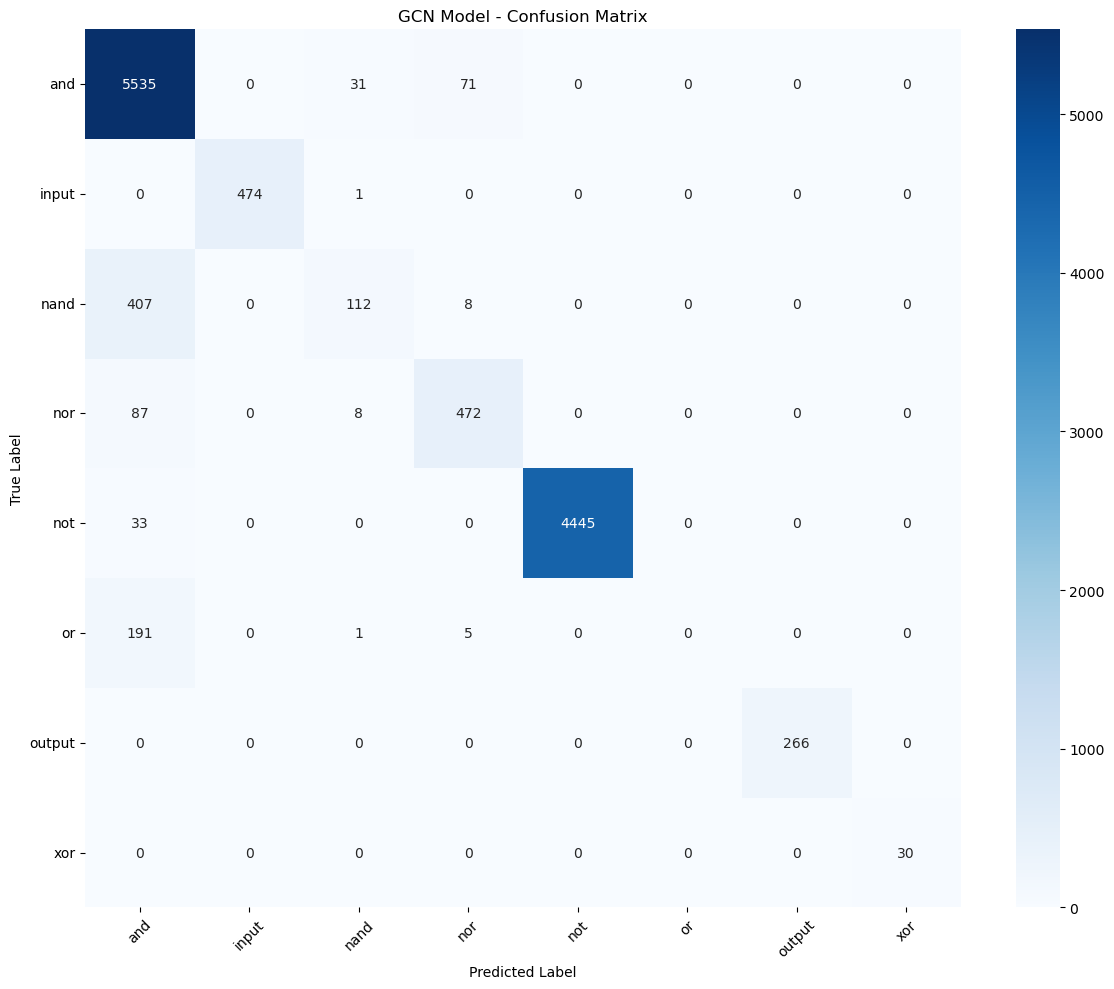


Classification Report:
              precision    recall  f1-score   support

         and       0.89      0.98      0.93      5637
       input       1.00      1.00      1.00       475
        nand       0.73      0.21      0.33       527
         nor       0.85      0.83      0.84       567
         not       1.00      0.99      1.00      4478
          or       0.00      0.00      0.00       197
      output       1.00      1.00      1.00       266
         xor       1.00      1.00      1.00        30

    accuracy                           0.93     12177
   macro avg       0.81      0.75      0.76     12177
weighted avg       0.91      0.93      0.91     12177


Overall Metrics:
Precision: 0.9120
Recall: 0.9308
F1-Score: 0.9141

Per-class Metrics:
Class and: Precision=0.8852, Recall=0.9819, F1=0.9310
Class input: Precision=1.0000, Recall=0.9979, F1=0.9989
Class nand: Precision=0.7320, Recall=0.2125, F1=0.3294
Class nor: Precision=0.8489, Recall=0.8325, F1=0.8406
Class not: Precisi

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [2]:
# Add these imports if not already present
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

# -----------------------------------
# Evaluate GCN Model Performance
# -----------------------------------

print("\n" + "="*50)
print("GCN MODEL PERFORMANCE METRICS")
print("="*50)

# Get predictions
model.eval()
with torch.no_grad():
    # Training predictions
    train_logits = model(graph, graph.ndata['features'])
    train_pred = train_logits[train_mask].argmax(dim=1)
    train_labels = graph.ndata['labels'][train_mask]
    train_accuracy = (train_pred == train_labels).float().mean().item()
    
    # Test predictions
    test_logits = model(graph, graph.ndata['features'])
    test_pred = test_logits[test_mask].argmax(dim=1)
    test_labels = graph.ndata['labels'][test_mask]
    test_accuracy = (test_pred == test_labels).float().mean().item()

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Convert to CPU numpy for sklearn metrics
test_pred_np = test_pred.cpu().numpy()
test_labels_np = test_labels.cpu().numpy()
train_pred_np = train_pred.cpu().numpy()
train_labels_np = train_labels.cpu().numpy()

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels_np, test_pred_np)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('GCN Model - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels_np, test_pred_np, 
                          target_names=label_encoder.classes_))

# Overall Precision, Recall, F1-Score
overall_precision = precision_score(test_labels_np, test_pred_np, average='weighted')
overall_recall = recall_score(test_labels_np, test_pred_np, average='weighted')
overall_f1 = f1_score(test_labels_np, test_pred_np, average='weighted')

print("\nOverall Metrics:")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1-Score: {overall_f1:.4f}")

# Per-class metrics
print("\nPer-class Metrics:")
precision_per_class = precision_score(test_labels_np, test_pred_np, average=None)
recall_per_class = recall_score(test_labels_np, test_pred_np, average=None)
f1_per_class = f1_score(test_labels_np, test_pred_np, average=None)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"Class {class_name}: Precision={precision_per_class[i]:.4f}, "
          f"Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")

# Additional: Training vs Test accuracy comparison
print(f"\nAccuracy Comparison:")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Gap: {abs(train_accuracy - test_accuracy)*100:.2f}%")

# Class distribution in test set
unique, counts = np.unique(test_labels_np, return_counts=True)
print(f"\nClass distribution in test set:")
for i, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([i])[0]
    print(f"  {class_name}: {count} samples ({count/len(test_labels_np)*100:.1f}%)")

In [3]:
# ==================== CELL 2: No Defense (Baseline for GAT) ====================
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# ---------- Parameters ----------
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

# ---------- Load sampled nodes ----------
sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()

rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total baseline attacks to run:", total)

# ---------- Loop over all sampled nodes ----------
for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"NoDef (GAT) label {label_name}"):
        # compute true grads for the target node
        grads_true = compute_true_grads(model, graph, target_idx)

        # observed grads = true grads (no defense)
        grads_obs = [g.clone() for g in grads_true]

        # run gradient inversion
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )

        rows.append({
            "defense": "None",
            "defense_key": "none",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

# ---------- Save results ----------
df_none = pd.DataFrame(rows)
df_none.to_csv("results_none_gat.csv", index=False)
print(f"Saved results_none_gat.csv (rows: {len(df_none)})")

# ---------- Per-class summary ----------
print("\nBaseline summary (GAT)  mean ± std:")
print(df_none.groupby("label_name")[["abs_l2", "rel_l2", "cos_sim"]].agg(["mean", "std", "count"]))


Total baseline attacks to run: 160


NoDef (GAT) label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [50:19<00:00, 150.96s/it]

Saved results_none_gat.csv (rows: 160)

Baseline summary (GAT)  mean ± std:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          1.933921  1.034339    20  0.903966  0.340726    20  0.582577   
input        5.560152  0.369158    20  0.810749  0.053891    20  0.706573   
nand         1.883475  1.908023    20  0.657821  0.174557    20  0.791886   
nor          3.244817  1.470983    20  0.794889  0.254794    20  0.610157   
not          1.704833  0.868283    20  0.910891  0.154383    20  0.482962   
or           1.531468  1.194486    20  0.644641  0.185290    20  0.813814   
output       6.359953  0.395079    20  0.756444  0.016739    20  0.858307   
xor         20.838398  0.978862    20  0.887262  0.019144    20  0.877914   

                            
                 std count  
label_name        

In [4]:
# ==================== CELL 3: Gradient Clipping + Perturbation (GAT) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

clip_value = 1.0
perturb_std = 0.05

recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total grad-clip attacks to run:", total)

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"GradClip (GAT) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = []
        for g in grads_true:
            g_clipped = torch.clamp(g, -clip_value, clip_value)
            g_noisy = g_clipped + torch.randn_like(g_clipped) * perturb_std
            grads_obs.append(g_noisy)
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Gradient Clipping + Perturbation",
            "defense_key": "clip_perturb",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_clip = pd.DataFrame(rows)
df_clip.to_csv("results_gat_gradclip_perturb.csv", index=False)
print(f"Saved results_gat_gradclip_perturb.csv (rows: {len(df_clip)})")
print("\nGradClip summary (GAT, mean ± std):")
print(df_clip.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Total grad-clip attacks to run: 160


GradClip (GAT) label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [30:07<00:00, 90.36s/it]

Saved results_gat_gradclip_perturb.csv (rows: 160)

GradClip summary (GAT, mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.163531  1.073211    20  1.016735  0.326116    20  0.451533   
input        5.642623  0.338604    20  0.822774  0.049311    20  0.653625   
nand         1.792613  1.674208    20  0.669477  0.190717    20  0.778667   
nor          3.053467  1.525311    20  0.733160  0.178083    20  0.683196   
not          2.017492  0.910915    20  1.119326  0.420845    20  0.398056   
or           1.751742  1.594411    20  0.713631  0.328240    20  0.728757   
output       6.384364  0.408138    20  0.759343  0.020873    20  0.849484   
xor         20.727778  0.898170    20  0.882548  0.009218    20  0.887627   

                            
                 std count  
label_

In [5]:
# ==================== CELL 4: Differential Privacy (GAT) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

dp_sigma = 0.1
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"DP (GAT) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + torch.randn_like(g) * dp_sigma for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Differential Privacy",
            "defense_key": "dp",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_dp = pd.DataFrame(rows)
df_dp.to_csv("results_gat_dp.csv", index=False)
print(f"Saved results_gat_dp.csv (rows: {len(df_dp)})")
print("\nDP summary (GAT, mean ± std):")
print(df_dp.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


DP (GAT) label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [28:46<00:00, 86.30s/it]

Saved results_gat_dp.csv (rows: 160)

DP summary (GAT, mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.210239  1.286971    20  1.064079  0.714366    20  0.506003   
input        5.524825  0.394480    20  0.805538  0.056450    20  0.700717   
nand         2.035971  1.715604    20  0.791154  0.270415    20  0.711485   
nor          3.160930  1.216663    20  0.772596  0.128973    20  0.694799   
not          1.894340  0.780426    20  1.053164  0.297719    20  0.396574   
or           1.586280  1.191018    20  0.682222  0.192912    20  0.775067   
output       6.406107  0.461104    20  0.761865  0.030691    20  0.831986   
xor         21.072167  1.041066    20  0.897448  0.032094    20  0.872785   

                            
                 std count  
label_name                

In [6]:
# ==================== CELL 5: Secure Aggregation (GAT) ====================
import numpy as np, pandas as pd, torch, random
from tqdm import tqdm

group_size = 5
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

all_labels = graph.ndata['labels'].cpu().numpy()
train_indices = torch.where(train_mask)[0].cpu().numpy()
label_to_trainlist = {int(lbl): np.intersect1d(np.where(all_labels==lbl)[0], train_indices).tolist()
                      for lbl in np.unique(all_labels)}

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"SecAgg (GAT) label {label_name}"):
        pool = label_to_trainlist.get(int(lbl), [])
        if len(pool) == 0:
            grads_obs = compute_true_grads(model, graph, target_idx)
        else:
            members = [target_idx]
            others = [i for i in pool if i != target_idx]
            k = min(len(others), group_size-1)
            if k > 0: members += random.sample(others, k)
            agg = None
            for m in members:
                g_m = compute_true_grads(model, graph, m)
                agg = [t.clone() for t in g_m] if agg is None else [a + b for a,b in zip(agg, g_m)]
            grads_obs = [a / float(len(members)) for a in agg]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Secure Aggregation",
            "defense_key": "secure_agg",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_secure = pd.DataFrame(rows)
df_secure.to_csv("results_gat_secureagg.csv", index=False)
print(f"Saved results_gat_secureagg.csv (rows: {len(df_secure)})")
print("\nSecureAgg summary (GAT, mean ± std):")
print(df_secure.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


SecAgg (GAT) label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [29:43<00:00, 89.17s/it]

Saved results_gat_secureagg.csv (rows: 160)

SecureAgg summary (GAT, mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.355473  1.328845    20  1.075026  0.331813    20  0.381602   
input        5.662066  0.464211    20  0.825569  0.067300    20  0.649210   
nand         2.446107  1.992490    20  0.942551  0.278215    20  0.482902   
nor          3.543213  1.266539    20  0.916540  0.345072    20  0.531818   
not          1.867137  0.843405    20  1.025483  0.251804    20  0.376232   
or           2.090546  1.323286    20  0.910067  0.296375    20  0.569270   
output       6.341247  0.373247    20  0.754297  0.014983    20  0.852713   
xor         20.957525  1.115794    20  0.892264  0.026815    20  0.876240   

                            
                 std count  
label_name  

In [7]:
# ==================== CELL 6: Model Quantization (GAT) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

quant_factor = 100.0
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"Quant (GAT) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [torch.round(g * quant_factor) / quant_factor for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Model Quantization",
            "defense_key": "quant",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_quant = pd.DataFrame(rows)
df_quant.to_csv("results_gat_quant.csv", index=False)
print(f"Saved results_gat_quant.csv (rows: {len(df_quant)})")
print("\nQuant summary (GAT, mean ± std):")
print(df_quant.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Quant (GAT) label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [33:22<00:00, 100.14s/it]

Saved results_gat_quant.csv (rows: 160)

Quant summary (GAT, mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.078070  0.981091    20  1.021521  0.428821    20  0.529696   
input        5.733202  0.378617    20  0.835676  0.049830    20  0.649414   
nand         1.777758  1.667042    20  0.649609  0.153222    20  0.842821   
nor          3.164391  1.497943    20  0.763563  0.178888    20  0.637026   
not          2.134495  0.988996    20  1.249095  0.708691    20  0.395634   
or           1.422563  1.180336    20  0.599809  0.191727    20  0.898461   
output       6.344123  0.438574    20  0.754451  0.024318    20  0.847829   
xor         20.689077  0.837492    20  0.880983  0.007260    20  0.887099   

                            
                 std count  
label_name          

In [8]:
# ==================== CELL 7: Adversarial Training style perturbation (GAT) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

perturb_eps = 0.02
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"AdvTrain (GAT) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + perturb_eps * torch.sign(torch.randn_like(g)) for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Adversarial Training",
            "defense_key": "adv_train",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_advtrain = pd.DataFrame(rows)
df_advtrain.to_csv("results_gat_advtrain.csv", index=False)
print(f"Saved results_gat_advtrain.csv (rows: {len(df_advtrain)})")
print("\nAdvTrain summary (GAT, mean ± std):")
print(df_advtrain.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


AdvTrain (GAT) label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [31:55<00:00, 95.78s/it]

Saved results_gat_advtrain.csv (rows: 160)

AdvTrain summary (GAT, mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.211515  1.036076    20  1.105459  0.465221    20  0.449529   
input        5.598329  0.288109    20  0.816241  0.040409    20  0.681892   
nand         1.888001  1.859728    20  0.711162  0.265095    20  0.731069   
nor          3.158019  1.368448    20  0.770560  0.185051    20  0.645142   
not          1.856419  0.994496    20  0.981871  0.182798    20  0.417645   
or           1.509152  1.182215    20  0.625690  0.166092    20  0.853243   
output       6.386059  0.430516    20  0.759918  0.037195    20  0.847811   
xor         20.718911  0.856045    20  0.882396  0.019759    20  0.890724   

                            
                 std count  
label_name    

/tmp/ipykernel_28792/3278188116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


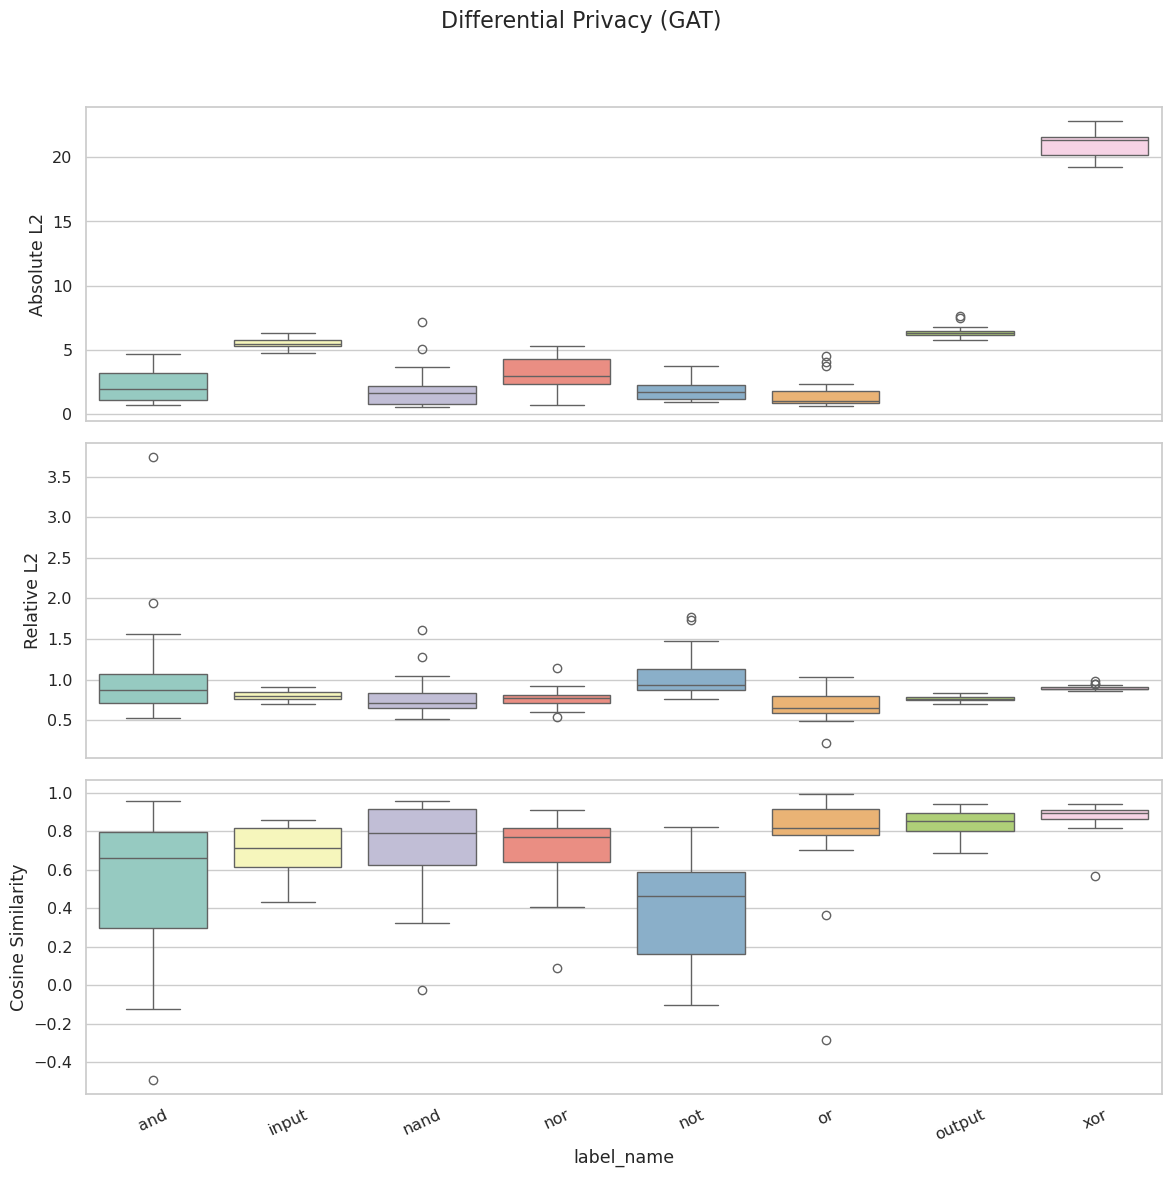


Summary for Differential Privacy (GAT):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.210239  1.286971    20  1.064079  0.714366    20  0.506003   
input        5.524825  0.394480    20  0.805538  0.056450    20  0.700717   
nand         2.035971  1.715604    20  0.791154  0.270415    20  0.711485   
nor          3.160930  1.216663    20  0.772596  0.128973    20  0.694799   
not          1.894340  0.780426    20  1.053164  0.297719    20  0.396574   
or           1.586280  1.191018    20  0.682222  0.192912    20  0.775067   
output       6.406107  0.461104    20  0.761865  0.030691    20  0.831986   
xor         21.072167  1.041066    20  0.897448  0.032094    20  0.872785   

                            
                 std count  
label_name                  
and         0.391131    

/tmp/ipykernel_28792/3278188116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


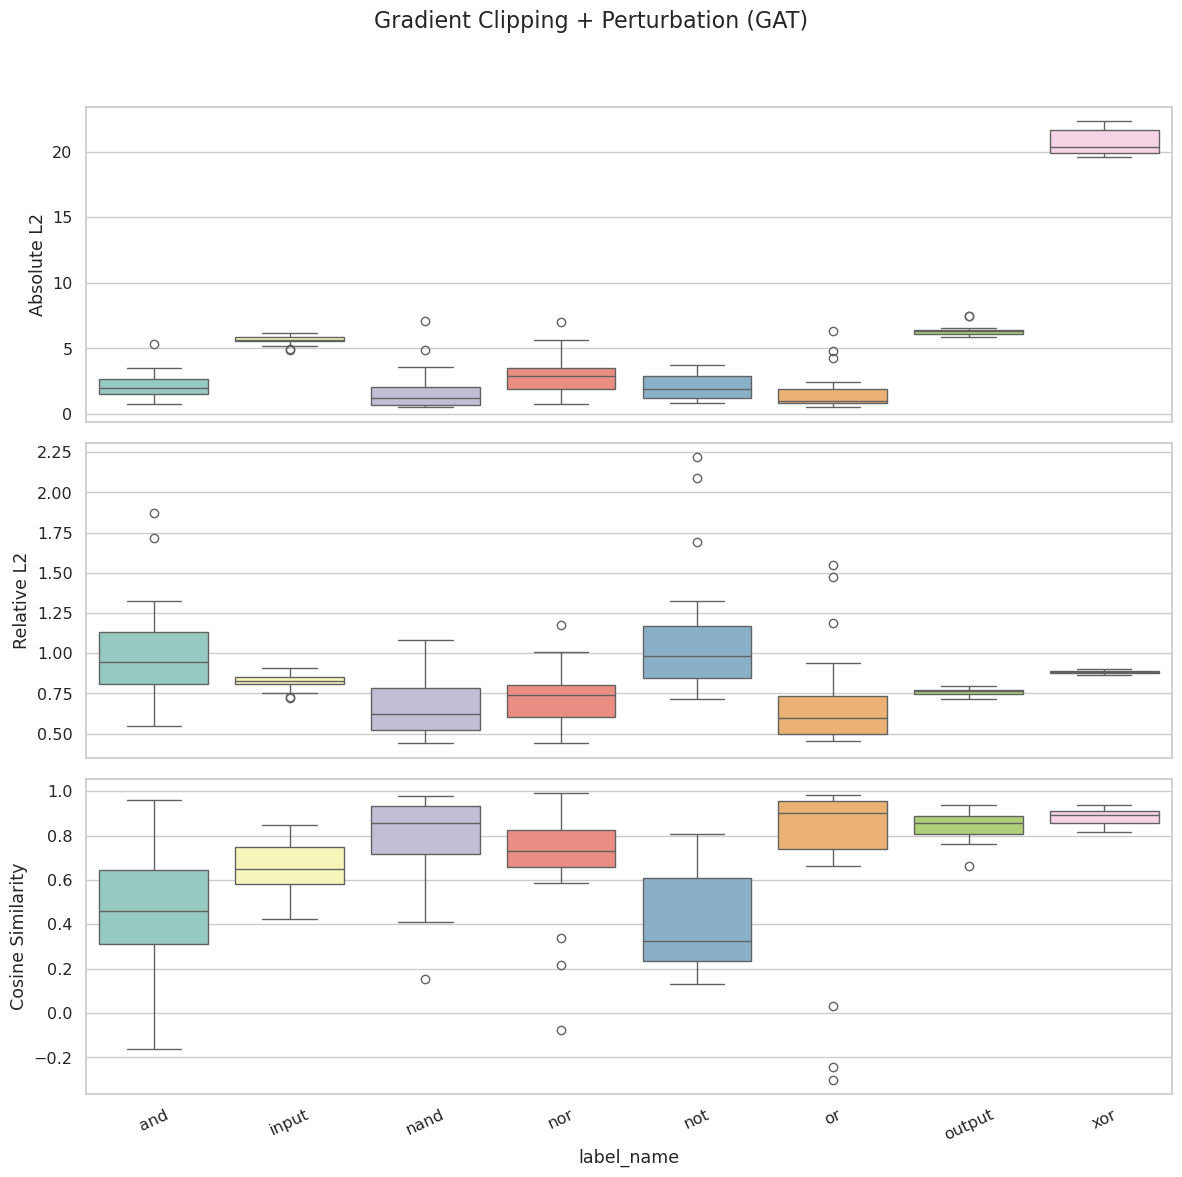


Summary for Gradient Clipping + Perturbation (GAT):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.163531  1.073211    20  1.016735  0.326116    20  0.451533   
input        5.642623  0.338604    20  0.822774  0.049311    20  0.653625   
nand         1.792613  1.674208    20  0.669477  0.190717    20  0.778667   
nor          3.053467  1.525311    20  0.733160  0.178083    20  0.683196   
not          2.017492  0.910915    20  1.119326  0.420845    20  0.398056   
or           1.751742  1.594411    20  0.713631  0.328240    20  0.728757   
output       6.384364  0.408138    20  0.759343  0.020873    20  0.849484   
xor         20.727778  0.898170    20  0.882548  0.009218    20  0.887627   

                            
                 std count  
label_name                  
and         

/tmp/ipykernel_28792/3278188116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


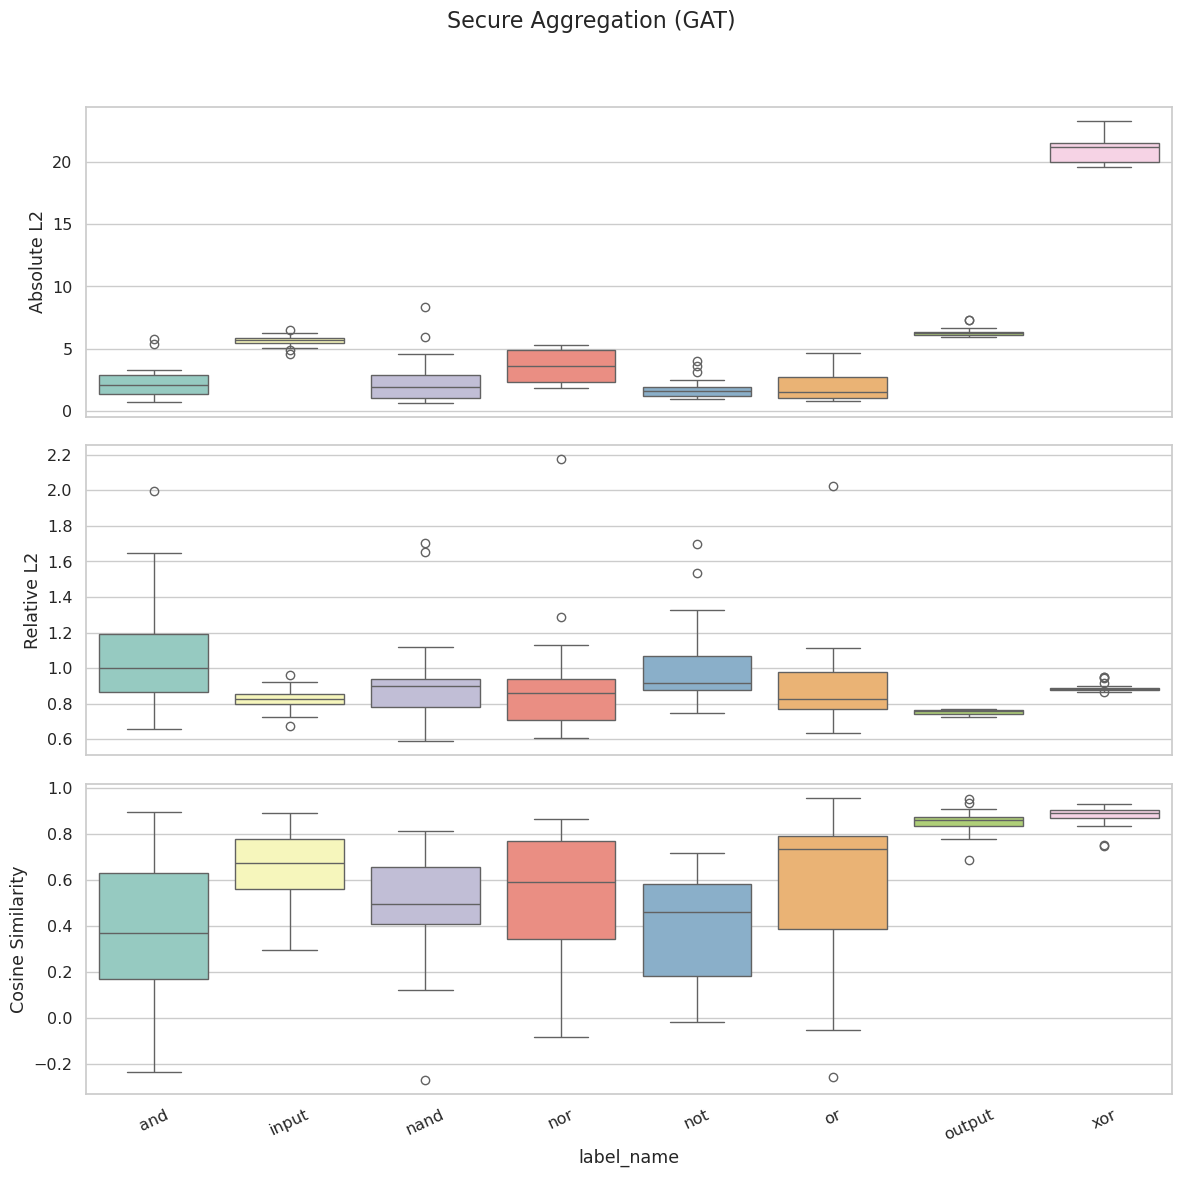


Summary for Secure Aggregation (GAT):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.355473  1.328845    20  1.075026  0.331813    20  0.381602   
input        5.662066  0.464211    20  0.825569  0.067300    20  0.649210   
nand         2.446107  1.992490    20  0.942551  0.278215    20  0.482902   
nor          3.543213  1.266539    20  0.916540  0.345072    20  0.531818   
not          1.867137  0.843405    20  1.025483  0.251804    20  0.376232   
or           2.090546  1.323286    20  0.910067  0.296375    20  0.569270   
output       6.341247  0.373247    20  0.754297  0.014983    20  0.852713   
xor         20.957525  1.115794    20  0.892264  0.026815    20  0.876240   

                            
                 std count  
label_name                  
and         0.308918    20

/tmp/ipykernel_28792/3278188116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


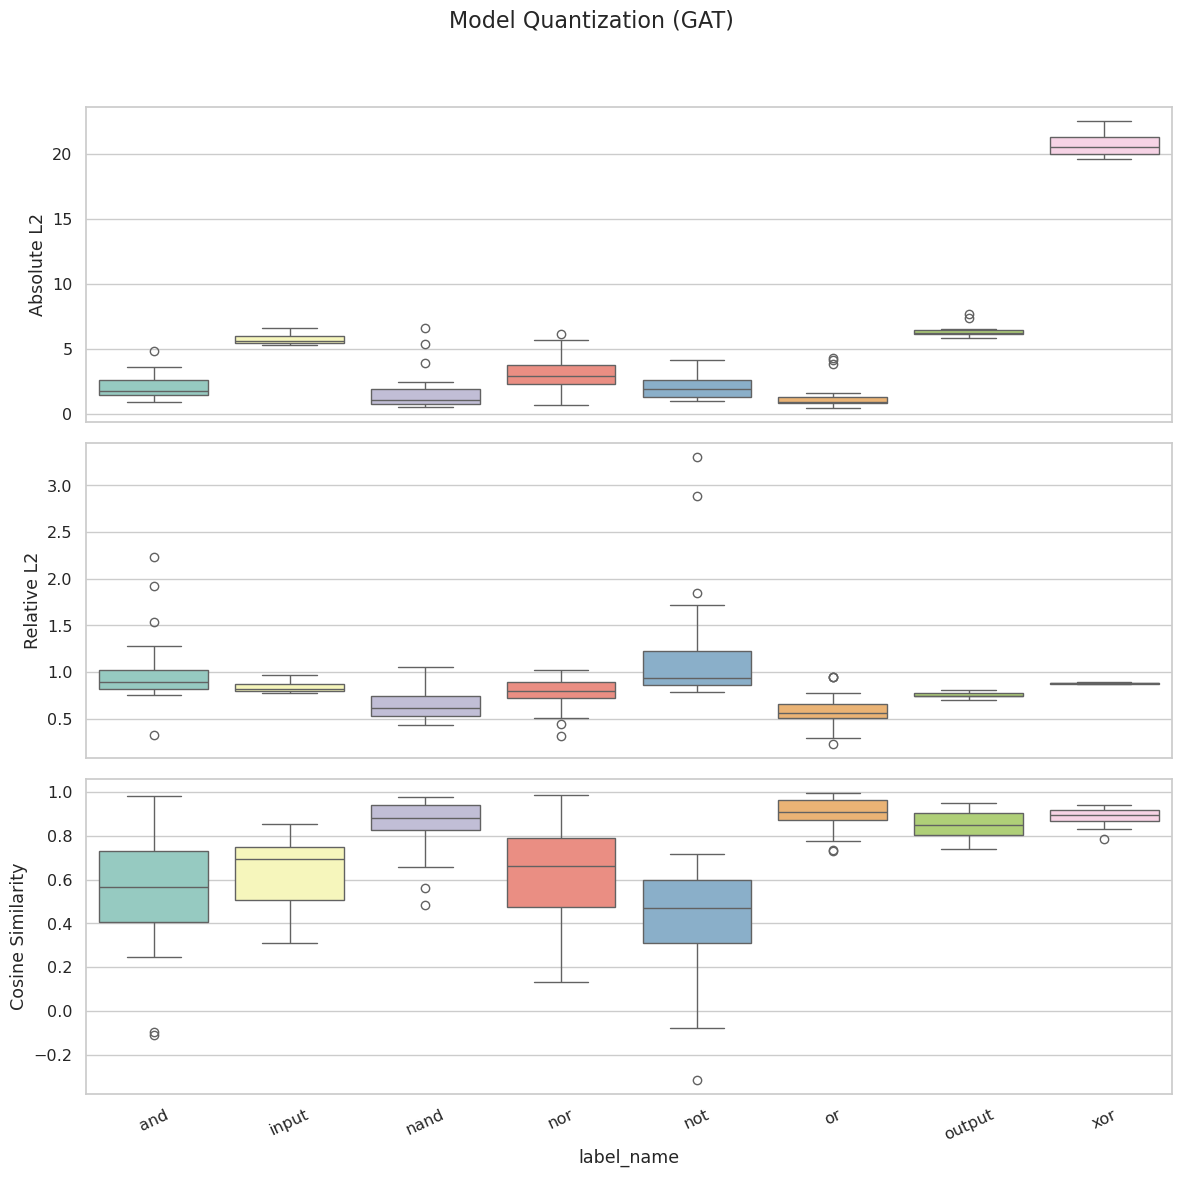


Summary for Model Quantization (GAT):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.078070  0.981091    20  1.021521  0.428821    20  0.529696   
input        5.733202  0.378617    20  0.835676  0.049830    20  0.649414   
nand         1.777758  1.667042    20  0.649609  0.153222    20  0.842821   
nor          3.164391  1.497943    20  0.763563  0.178888    20  0.637026   
not          2.134495  0.988996    20  1.249095  0.708691    20  0.395634   
or           1.422563  1.180336    20  0.599809  0.191727    20  0.898461   
output       6.344123  0.438574    20  0.754451  0.024318    20  0.847829   
xor         20.689077  0.837492    20  0.880983  0.007260    20  0.887099   

                            
                 std count  
label_name                  
and         0.288216    20

/tmp/ipykernel_28792/3278188116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_28792/3278188116.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


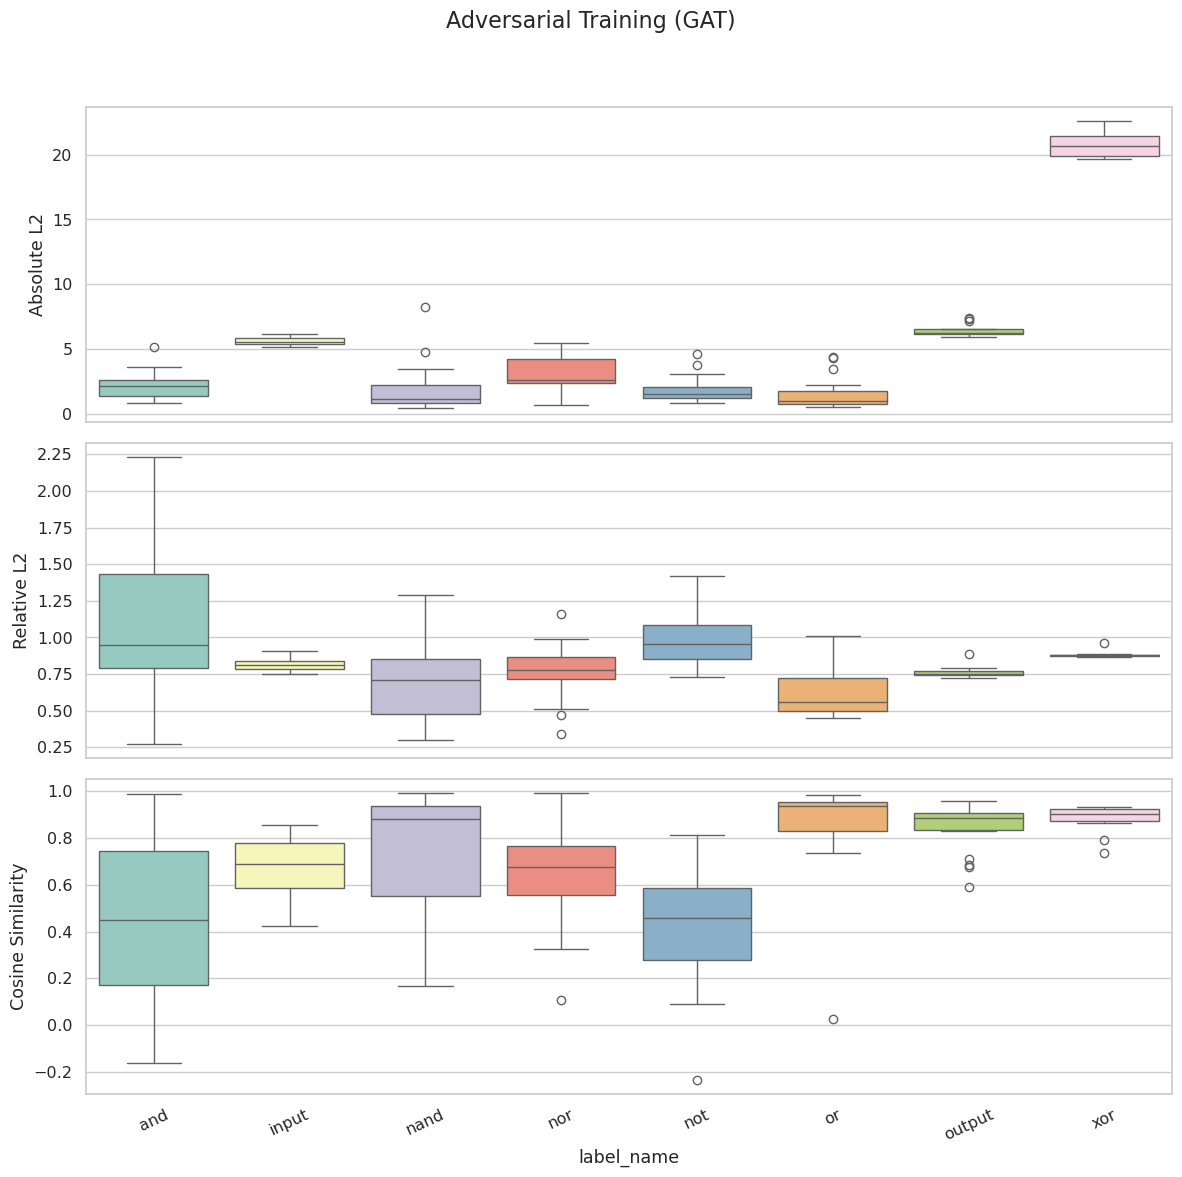


Summary for Adversarial Training (GAT):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.211515  1.036076    20  1.105459  0.465221    20  0.449529   
input        5.598329  0.288109    20  0.816241  0.040409    20  0.681892   
nand         1.888001  1.859728    20  0.711162  0.265095    20  0.731069   
nor          3.158019  1.368448    20  0.770560  0.185051    20  0.645142   
not          1.856419  0.994496    20  0.981871  0.182798    20  0.417645   
or           1.509152  1.182215    20  0.625690  0.166092    20  0.853243   
output       6.386059  0.430516    20  0.759918  0.037195    20  0.847811   
xor         20.718911  0.856045    20  0.882396  0.019759    20  0.890724   

                            
                 std count  
label_name                  
and         0.331970    

In [9]:
# ==================== CELL 8: Plotting all GAT results ====================
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os

sns.set(style="whitegrid", font_scale=1.05)

files = {
    "Differential Privacy": "results_gat_dp.csv",
    "Gradient Clipping + Perturbation": "results_gat_gradclip_perturb.csv",
    "Secure Aggregation": "results_gat_secureagg.csv",
    "Model Quantization": "results_gat_quant.csv",
    "Adversarial Training": "results_gat_advtrain.csv"
}

for pretty_name, fname in files.items():
    if not os.path.exists(fname):
        print(f"Warning: {fname} not found  skipping {pretty_name}")
        continue
    df = pd.read_csv(fname)
    if df.empty:
        print(f"{fname} is empty  skipping")
        continue

    order = sorted(df["label"].unique())
    label_order = [df[df["label"]==l]["label_name"].iloc[0] for l in order]

    fig, axs = plt.subplots(3,1, figsize=(12,12), sharex=True)
    fig.suptitle(f"{pretty_name} (GAT)", fontsize=16)

    sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
    axs[0].set_ylabel("Absolute L2"); axs[0].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
    axs[1].set_ylabel("Relative L2"); axs[1].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")
    axs[2].set_ylabel("Cosine Similarity"); axs[2].tick_params(axis="x", rotation=25)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    print(f"\nSummary for {pretty_name} (GAT):")
    print(df.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))
